In [1]:
import os, sys
# Run from notebooks/ or project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [2]:
import warnings
warnings.filterwarnings('ignore')


import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from data.dataloader import tf_data_generator
from estimator.shaffer import fit_monotone_regressions, reconstruct_mu_sigma_from_phi
from estimator.QIS import QIS
from models.gru_denoiser import BiGRUSpectralDenoiserTensorFlow

os.makedirs('images', exist_ok=True)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
!.venv/bin/python scripts/train_syntheticdata.py 2>&1   

Parameters: 27,393  — warm-started from models/bigru_weights_nomiss.weights.h5
Pre-collecting 20 val batches...


Epoch 1, Loss: 0.061421, Val: 0.073413, Best: 0.073413, P: 0/15


Epoch 2, Loss: 0.076203, Val: 0.073335, Best: 0.073335, P: 0/15


Epoch 3, Loss: 0.072916, Val: 0.073259, Best: 0.073259, P: 0/15


Epoch 4, Loss: 0.075841, Val: 0.073185, Best: 0.073185, P: 0/15


...

Epoch 53, Loss: 0.083019, Val: 0.072624, Best: 0.072590, P: 12/15


Epoch 54, Loss: 0.075599, Val: 0.072620, Best: 0.072590, P: 13/15


Epoch 55, Loss: 0.073865, Val: 0.072613, Best: 0.072590, P: 14/15


Epoch 56, Loss: 0.071183, Val: 0.072598, Best: 0.072590, P: 15/15
EarlyStop @ epoch 56
Restored best weights (val=0.072590)

Saved → models/bigru_weights_syntheticdata.weights.h5


Training curve saved → images/training_loss_syntheticdata.png


In [4]:
# Model trained by scripts/train_syntheticdata.py
model = BiGRUSpectralDenoiserTensorFlow(hidden_size=64)
_ = model(tf.zeros((1, 10, 5)))
model.load_weights('models/bigru_weights_syntheticdata.weights.h5')
print(f'Model loaded — {model.count_params():,} parameters')

Model loaded — 27,393 parameters


## 1  Background

### The Schäffer estimator

Under a **monotone missing pattern** (asset $k$ unobserved for $t < t_k$, with $t_0 \le t_1 \le \cdots \le t_{N-1}$),
the joint Gaussian likelihood factors into independent conditional regressions:
$$
p(r_0,\ldots,r_{N-1}) = p(r_0)\cdot\prod_{k=1}^{N-1} p(r_k\mid r_0,\ldots,r_{k-1})
$$
Each conditional is an OLS regression estimated on the window $[t_k,T]$.
This is the **MLE** for the monotone pattern (Anderson 1957) — always PSD, uses all pairwise observations.

**Critical limitation:** the last regression has $T - t_{N-1} \approx T/2$ observations but $N-1$ regressors.
Above $q \approx 0.5$ the system is underdetermined, minimum-norm OLS overfits, and the covariance blows up.

### Why Schäffer ≈ pairwise MLE

The dominant error at finite $q = N/T$ is **spectral noise**: eigenvalue estimates are biased by $O(\sqrt{q})$.
Schäffer has no shrinkage. Pairwise MLE has no shrinkage. Both commit the same spectral error.

> **The real gap is not pairwise MLE vs. Schäffer. It is unshrunken vs. shrunken.**
> That is what QIS and the NN exploit.

### Estimators compared

| Estimator | Uses all data? | PSD? | Shrinkage? | Notes |
|---|:---:|:---:|:---:|---|
| **Pairwise MLE** | ✓ | ✗ | ✗ | Naive baseline |
| **Schäffer MLE** | ✓ | ✓ | ✗ | MLE but no shrinkage → ≈ pairwise MLE |
| **QIS (sync)**   | ✗ | ✓ | ✓ | Loses asynchronous data, but shrinks |
| **NN (ours)**    | ✓ | ✓ | ✓ | All data + learned shrinkage |
| **Oracle**       | — | ✓ | ✓ | True eig. in empirical eigenvectors |
| **Opt-Oracle**   | — | ✓ | ✓ | $d^*_j=(\hat{Q}^\top C_\text{true}\hat{Q})_{jj}$ — lower bound |

## 2  Stambaugh MLE: PSD but unshrunken (and broken at high $q$)

Single example at $q = 0.5$ (overdetermined regime — Stambaugh does not blow up here).  
Goal: show Stambaugh is PSD yet its spectrum tracks pairwise MLE, not the true spectrum.

**Why Stambaugh fails at high $q$:** the monotone MLE regresses asset $k$ on the $k-1$
earlier-starting assets using only the $T - t_k$ jointly-observed time steps.
For the last asset this window has $\approx T(1-\alpha)$ observations but $N-1$ regressors.
Above $q \approx 0.5$ (sooner with missing data) the system is underdetermined:
OLS returns the minimum-norm solution, which overfits the small sample and produces
a reconstructed covariance with wildly inflated eigenvalues.

**Stambaugh is therefore excluded from all further comparisons.**

In [5]:
def frob_loss(A, B):
    """||A - B||_F / N."""
    return np.linalg.norm(A.astype(float) - B.astype(float), 'fro') / A.shape[0]


def stambaugh_cov(R_np):
    """Monotone MLE (Stambaugh 1997 / Anderson 1957) — demo only, excluded from sweeps.

    Sort assets by first-obs time so each asset's regressors are fully
    observed at its own start time, run regressions, then unsort the result.
    Fails (inflated eigenvalues) when q >= ~0.5 due to underdetermined OLS.
    """
    N = R_np.shape[0]
    t_vec = np.array([int(np.argmax(~np.isnan(R_np[k]))) for k in range(N)])
    order = np.argsort(t_vec)
    try:
        phi = fit_monotone_regressions(R_np[order], t_vec[order])
        _, S = reconstruct_mu_sigma_from_phi(phi)
    except Exception:
        return None
    inv = np.argsort(order)
    return S[np.ix_(inv, inv)]


def qis_sync_cov(R_np):
    born = int((~np.isnan(R_np)).all(axis=0).sum())
    if born < 3:
        return None
    return QIS(R_np[:, -born:].T)   # QIS expects (T, N)


def run_all_estimators(model, batch):
    """Return per-sample Frobenius losses for NN, QIS, EmpMLE, Oracle, OptOracle."""
    input_seq, Q_emp, Sigma_true, T, Sigma_hat_diag, R_hat = batch

    R_np          = R_hat.numpy()
    Sigma_true_np = Sigma_true.numpy()
    Q_np          = Q_emp.numpy()
    D_sqrt_np     = np.sqrt(np.maximum(Sigma_hat_diag.numpy(), 1e-12))
    lam_emp_np    = input_seq.numpy()[:, :, 0]
    lam_pred_np   = model(input_seq, training=False).numpy()

    B = R_np.shape[0]
    losses = {k: np.full(B, np.nan)
              for k in ['NN', 'QIS', 'EmpMLE', 'Oracle', 'OptOracle']}

    for b in range(B):
        St  = Sigma_true_np[b]
        Q_b = Q_np[b]
        D_b = np.diag(D_sqrt_np[b])

        Corr_emp  = Q_b @ np.diag(lam_emp_np[b]) @ Q_b.T
        Sigma_emp = D_b @ Corr_emp @ D_b
        Sigma_nn  = D_b @ (Q_b @ np.diag(lam_pred_np[b]) @ Q_b.T) @ D_b

        Sigma_qis = qis_sync_cov(R_np[b])
        if Sigma_qis is None:
            Sigma_qis = Sigma_emp

        d_true    = np.sqrt(np.maximum(np.diag(St), 1e-12))
        Corr_true = St.astype(float) / np.outer(d_true, d_true)
        lam_true  = np.linalg.eigvalsh(Corr_true)

        Sigma_oracle = D_b @ (Q_b @ np.diag(lam_true) @ Q_b.T) @ D_b
        d_opt        = np.maximum(np.diag(Q_b.T @ Corr_true @ Q_b), 0.0)
        Sigma_opt    = D_b @ (Q_b @ np.diag(d_opt) @ Q_b.T) @ D_b

        for name, S in [('NN', Sigma_nn), ('QIS', Sigma_qis), ('EmpMLE', Sigma_emp),
                         ('Oracle', Sigma_oracle), ('OptOracle', Sigma_opt)]:
            losses[name][b] = frob_loss(S, St)

    return losses


Pairwise MLE  — min eigenvalue: -0.1604  (can be < 0)
Stambaugh MLE — min eigenvalue: 0.0000  (always >= 0 by construction)


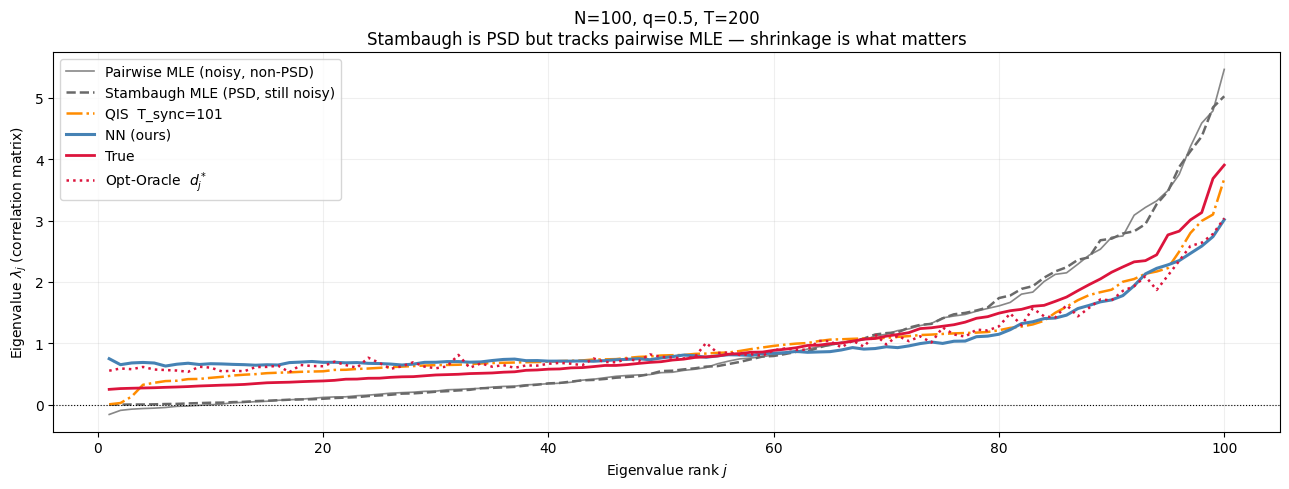

1.62778290243112
1.0297473573706493


In [6]:
N_EX, Q_EX = 100, 0.5
np.random.seed(0); tf.random.set_seed(0)

gen_ex = tf_data_generator(
    batch_size=1, missing_constant=2,
    N_min=N_EX, N_max=N_EX, q_min=Q_EX, q_max=Q_EX,
)
input_seq_ex, Q_emp_ex, Sigma_true_ex, T_ex, _, R_hat_ex = next(gen_ex)
R_np_ex = R_hat_ex.numpy()[0]

Sigma_t  = Sigma_true_ex.numpy()[0]
d_t      = np.sqrt(np.maximum(np.diag(Sigma_t), 1e-12))
Corr_t   = Sigma_t / np.outer(d_t, d_t)
lam_true = np.linalg.eigvalsh(Corr_t)
lam_emp  = input_seq_ex.numpy()[0, :, 0]
lam_pred = model(input_seq_ex, training=False).numpy()[0]

Q_np_ex = Q_emp_ex.numpy()[0]                                   # (N, N)
d_opt   = np.maximum(np.diag(Q_np_ex.T @ Corr_t @ Q_np_ex), 0.0)  # opt-oracle per eigenmode


Sigma_stamb_ex = stambaugh_cov(R_np_ex)
d_sh      = np.sqrt(np.maximum(np.diag(Sigma_stamb_ex), 1e-12))
lam_stamb = np.linalg.eigvalsh(Sigma_stamb_ex / np.outer(d_sh, d_sh))

Sigma_qis_ex = qis_sync_cov(R_np_ex)
d_q      = np.sqrt(np.maximum(np.diag(Sigma_qis_ex), 1e-12))
lam_qis  = np.linalg.eigvalsh(Sigma_qis_ex / np.outer(d_q, d_q))
sync_len = int((~np.isnan(R_np_ex)).all(axis=0).sum())

print(f'Pairwise MLE  — min eigenvalue: {lam_emp.min():.4f}  (can be < 0)')
print(f'Stambaugh MLE — min eigenvalue: {lam_stamb.min():.4f}  (always >= 0 by construction)')

j = np.arange(1, N_EX + 1)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(j, lam_emp,   color='dimgrey',        lw=1.2, alpha=0.8, label='Pairwise MLE (noisy, non-PSD)')
ax.plot(j, lam_stamb, color='dimgrey',        lw=1.8, ls='--',   label='Stambaugh MLE (PSD, still noisy)')
ax.plot(j, lam_qis,   color='darkorange',     lw=1.8, ls='-.',   label=f'QIS  T_sync={sync_len}')
ax.plot(j, lam_pred,  color='steelblue',      lw=2.2,            label='NN (ours)')
ax.plot(j, lam_true,  color='crimson',        lw=2.0, ls='-',    label='True')
ax.plot(j, d_opt,     color='crimson',       lw=1.8, ls=':',    label='Opt-Oracle  $d^*_j$')
ax.axhline(0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Eigenvalue rank $j$')
ax.set_ylabel('Eigenvalue $\lambda_j$ (correlation matrix)')
ax.set_title(f'N={N_EX}, q={Q_EX:.1f}, T={int(T_ex)}\n'
             'Stambaugh is PSD but tracks pairwise MLE — shrinkage is what matters')
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('images/schaffer_psd_demo.png', dpi=150)
plt.show()


print(np.linalg.norm(d_opt - lam_qis))
print(np.linalg.norm(d_opt - lam_pred))


## 3  Frobenius loss vs $q$

Fixed $N = 100$, `missing_constant = 2` (each asset observed ≥ $T/2$ timesteps).  
All five estimators evaluated on the same batches via `run_all_estimators`.

In [7]:
Q_GRID  = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.5]
N_FIXED = 100
N_REPS  = 40
BATCH   = 64

ESTIMATOR_KEYS = ['NN', 'QIS', 'EmpMLE', 'Oracle', 'OptOracle']
results = {k: [[] for _ in Q_GRID] for k in ESTIMATOR_KEYS}

for qi, q_val in enumerate(Q_GRID):
    print(f'q = {q_val:.2f}', end='  ', flush=True)
    gen = tf_data_generator(
        batch_size=BATCH, missing_constant=2,
        N_min=N_FIXED, N_max=N_FIXED,
        q_min=q_val, q_max=q_val,
    )
    for _ in range(N_REPS):
        L = run_all_estimators(model, next(gen))
        for k in ESTIMATOR_KEYS:
            results[k][qi].extend(L[k].tolist())

for k in ESTIMATOR_KEYS:
    results[k] = [np.array(v) for v in results[k]]
print('\nSweep done.')


q = 0.30  

q = 0.40  

q = 0.50  

q = 0.60  

q = 0.70  

...

q = 1.10  

q = 1.20  

q = 1.30  

q = 1.50  


Sweep done.


### 3.1  Summary table

In [8]:
STYLE = {
    'EmpMLE':    ('dimgrey',    '-',  'Pairwise MLE'),
    'QIS':       ('darkorange', '-',  'QIS (sync window)'),
    'NN':        ('steelblue',  '-',  'NN (ours)'),
    'Oracle':    ('crimson',    '--', 'Oracle  ($\lambda^\mathrm{true}$ in $\hat{Q}$)'),
    'OptOracle': ('seagreen',   ':',  'Opt-Oracle  $d^*_j=(\hat{Q}^\top C_\mathrm{true}\hat{Q})_{jj}$'),
}

qs_arr  = np.array(Q_GRID)
means   = {k: np.array([np.nanmean(results[k][qi])   for qi in range(len(Q_GRID))]) for k in ESTIMATOR_KEYS}
medians = {k: np.array([np.nanmedian(results[k][qi]) for qi in range(len(Q_GRID))]) for k in ESTIMATOR_KEYS}

print(f"{'q':>5}  {'EmpMLE':>8}  {'QIS':>8}  {'NN':>8}  {'Oracle':>8}  {'OptOracle':>10}")
print('-' * 60)
for qi, q_val in enumerate(Q_GRID):
    print(f"{q_val:5.2f}  {means['EmpMLE'][qi]:8.4f}  {means['QIS'][qi]:8.4f}  "
          f"{means['NN'][qi]:8.4f}  {means['Oracle'][qi]:8.4f}  {means['OptOracle'][qi]:10.4f}")


    q    EmpMLE       QIS        NN    Oracle   OptOracle
------------------------------------------------------------
 0.30    0.0663    0.0607    0.0606    0.0570      0.0536
 0.40    0.0765    0.0650    0.0633    0.0628      0.0584
 0.50    0.0855    0.0691    0.0653    0.0671      0.0616
 0.60    0.0940    0.0709    0.0673    0.0708      0.0644
 0.70    0.1019    0.0754    0.0720    0.0757      0.0687
 0.80    0.1086    0.0782    0.0744    0.0790      0.0712
 0.90    0.1157    0.0797    0.0762    0.0815      0.0730
 1.00    0.1218    0.0821    0.0787    0.0845      0.0754
 1.10    0.1283    0.0807    0.0771    0.0845      0.0747
 1.20    0.1343    0.0810    0.0772    0.0858      0.0752
 1.30    0.1399    0.0853    0.0817    0.0900      0.0791
 1.50    0.1503    0.0855    0.0822    0.0919      0.0798


## 4  Main plots

### 4.1  Frobenius loss vs $q$

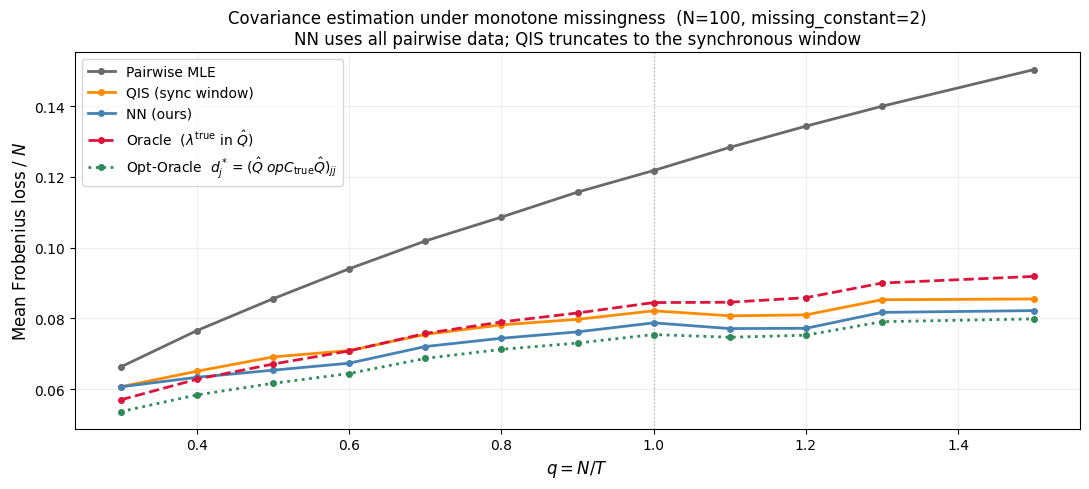

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
for key, (color, ls, label) in STYLE.items():
    y = means[key]
    s = medians[key]
    ax.plot(qs_arr, y, color=color, ls=ls, lw=2.0, marker='o', ms=4, label=label)
ax.axvline(x=1, color='grey', lw=1, ls=':', alpha=0.5)
ax.set_xlabel('$q = N/T$', fontsize=12)
ax.set_ylabel('Mean Frobenius loss / $N$', fontsize=12)
ax.set_title(
    f'Covariance estimation under monotone missingness  (N={N_FIXED}, missing_constant=2)\n'
    'NN uses all pairwise data; QIS truncates to the synchronous window',
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('images/comparison_missingness_qcurve.png', dpi=150)
plt.show()

### 4.2  NN advantage vs competing estimators

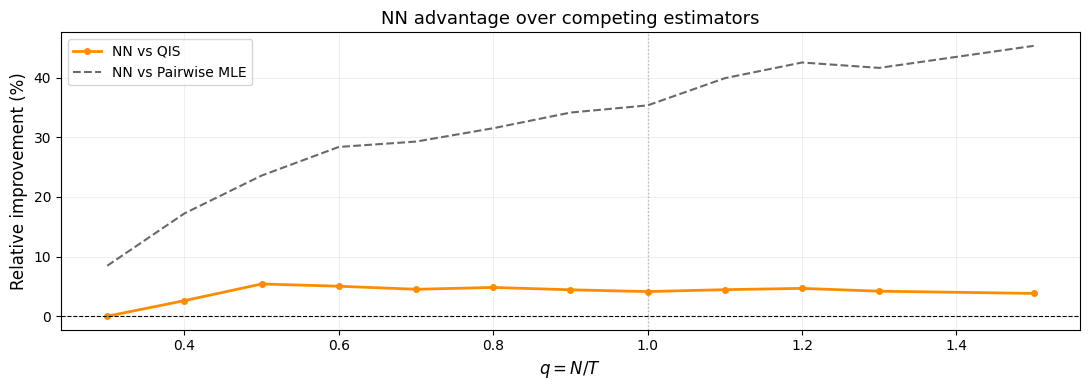

In [10]:
def gain_pct(ref, nn): return (ref - nn) / ref * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(qs_arr, gain_pct(means['QIS'],    means['NN']),
        color='darkorange', lw=2, marker='o', ms=4, label='NN vs QIS')
ax.plot(qs_arr, gain_pct(means['EmpMLE'], means['NN']),
        color='dimgrey', lw=1.5, ls='--', label='NN vs Pairwise MLE')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(1, color='grey',  lw=1,   ls=':', alpha=0.5)
ax.set_xlabel('$q = N/T$', fontsize=12)
ax.set_ylabel('Relative improvement (%)', fontsize=12)
ax.set_title('NN advantage over competing estimators', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('images/comparison_nn_gain_vs_all.png', dpi=150)
plt.show()


## 5  Conclusion

**Schäffer MLE** is PSD and uses all pairwise data — yet its Frobenius loss matches pairwise MLE.
The reason: both lack eigenvalue shrinkage, and shrinkage is the dominant source of gain at finite $q$.

**NN vs QIS:** the NN beats QIS across the full $q$ range because QIS discards asynchronous observations
while the NN exploits the full pairwise history and learns the correct shrinkage function.

**NN vs Opt-Oracle:** the residual gap is small, confirming the NN is close to the theoretical lower bound
for any estimator of the form $\hat{Q}\,\mathrm{diag}(\hat{d})\,\hat{Q}^\top$.

## 6  Frobenius loss vs missingness $\alpha$ (fixed $q$)

Fixed $N = 100$, $q = 0.8$.  
`missing_constant` $= m$ (integer) means each asset's observation window is drawn from
$\mathrm{Uniform}(\lfloor T/m \rfloor,\, T)$, so the **average fraction of data missing**
per asset is $\alpha = (m-1)/(2m)$.

| $m$ | $\alpha$ |
|-----|----------|
| 1 | 0 % — no missing data |
| 2 | 25 % — each asset observed at least $T/2$ steps |
| 4 | 37.5 % |
| 8 | 43.75 % — each asset observed at least $T/8$ steps |

QIS's synchronous window shrinks as $\alpha$ grows; the NN keeps exploiting all pairwise observations.

In [11]:
Q_FIXED  = 0.8
N_FIXED2 = 100
N_REPS2  = 80
BATCH2   = 64

MC_GRID   = [1, 2, 3, 4, 6, 8]   # must be integers: tf_make_random_pattern_vecto does T // mc (int32)
alpha_avg = [(mc - 1) / (2 * mc) for mc in MC_GRID]   # E[fraction missing per asset]

results_mc = {k: [[] for _ in MC_GRID] for k in ESTIMATOR_KEYS}

np.random.seed(0); tf.random.set_seed(0)
for mi, mc_val in enumerate(MC_GRID):
    print(f'mc={mc_val}  α≈{alpha_avg[mi]:.1%}', end='  ', flush=True)
    gen = tf_data_generator(
        batch_size=BATCH2, missing_constant=mc_val,
        N_min=N_FIXED2, N_max=N_FIXED2,
        q_min=Q_FIXED, q_max=Q_FIXED,
    )
    for _ in range(N_REPS2):
        L = run_all_estimators(model, next(gen))
        for k in ESTIMATOR_KEYS:
            results_mc[k][mi].extend(L[k].tolist())

for k in ESTIMATOR_KEYS:
    results_mc[k] = [np.array(v) for v in results_mc[k]]
print('\nSweep done.')

mc=1  α≈0.0%  

mc=2  α≈25.0%  

mc=3  α≈33.3%  

mc=4  α≈37.5%  

mc=6  α≈41.7%  

mc=8  α≈43.8%  


Sweep done.


In [12]:
means_mc   = {k: np.array([np.nanmean(results_mc[k][mi])   for mi in range(len(MC_GRID))]) for k in ESTIMATOR_KEYS}
medians_mc = {k: np.array([np.nanmedian(results_mc[k][mi]) for mi in range(len(MC_GRID))]) for k in ESTIMATOR_KEYS}
alpha_arr  = np.array(alpha_avg)

print(f"{'mc':>5}  {'α':>7}  {'EmpMLE':>8}  {'QIS':>8}  {'NN':>8}  {'Oracle':>8}  {'OptOracle':>10}")
print('-' * 65)
for mi, mc_val in enumerate(MC_GRID):
    print(f"{mc_val:5.1f}  {alpha_avg[mi]:7.1%}  {means_mc['EmpMLE'][mi]:8.4f}  {means_mc['QIS'][mi]:8.4f}  "
          f"{means_mc['NN'][mi]:8.4f}  {means_mc['Oracle'][mi]:8.4f}  {means_mc['OptOracle'][mi]:10.4f}")


   mc        α    EmpMLE       QIS        NN    Oracle   OptOracle
-----------------------------------------------------------------
  1.0     0.0%    0.0905    0.0655    0.0693    0.0705      0.0647
  2.0    25.0%    0.1088    0.0777    0.0741    0.0787      0.0709
  3.0    33.3%    0.1202    0.0820    0.0752    0.0818      0.0727
  4.0    37.5%    0.1285    0.0865    0.0777    0.0852      0.0754
  6.0    41.7%    0.1414    0.0880    0.0788    0.0874      0.0763
  8.0    43.8%    0.1504    0.0912    0.0814    0.0905      0.0787


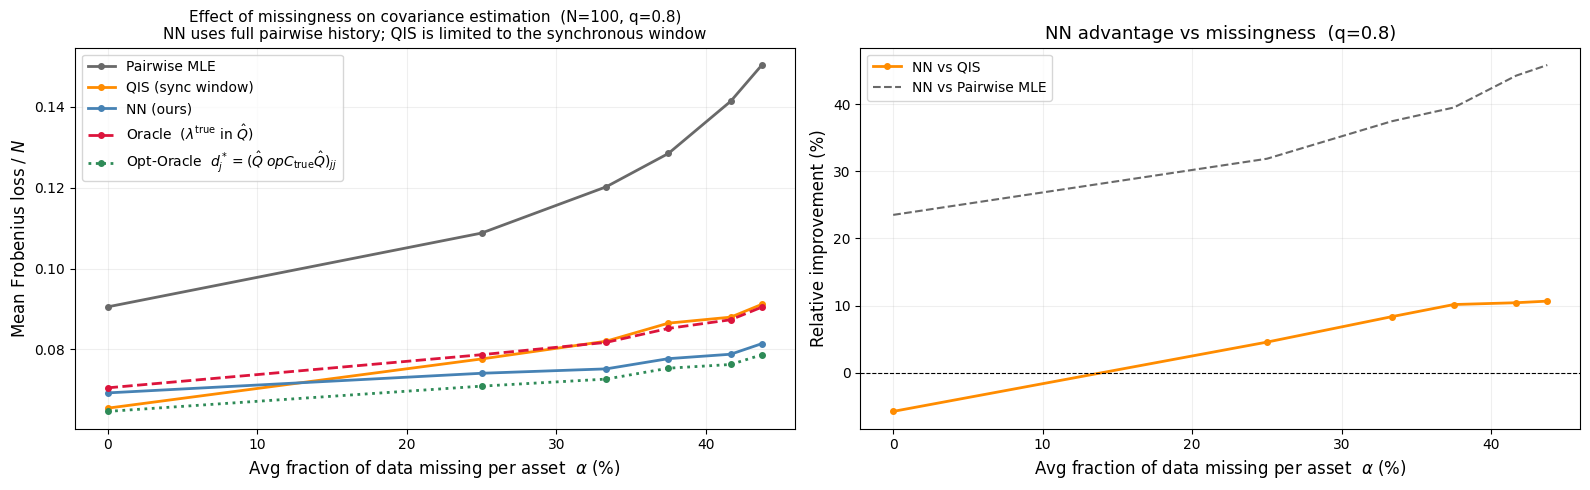

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = alpha_arr * 100   # percent

# ---- left: absolute losses ----
ax = axes[0]
for key, (color, ls, label) in STYLE.items():
    ax.plot(x, means_mc[key], color=color, ls=ls, lw=2.0, marker='o', ms=4, label=label)
ax.set_xlabel(r'Avg fraction of data missing per asset  $\alpha$ (%)', fontsize=12)
ax.set_ylabel('Mean Frobenius loss / $N$', fontsize=12)
ax.set_title(
    f'Effect of missingness on covariance estimation  (N={N_FIXED2}, q={Q_FIXED})\n'
    'NN uses full pairwise history; QIS is limited to the synchronous window',
    fontsize=11,
)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)

# ---- right: NN relative gain ----
ax = axes[1]
ax.plot(x, gain_pct(means_mc['QIS'],    means_mc['NN']),
        color='darkorange', lw=2, marker='o', ms=4, label='NN vs QIS')
ax.plot(x, gain_pct(means_mc['EmpMLE'], means_mc['NN']),
        color='dimgrey', lw=1.5, ls='--', label='NN vs Pairwise MLE')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel(r'Avg fraction of data missing per asset  $\alpha$ (%)', fontsize=12)
ax.set_ylabel('Relative improvement (%)', fontsize=12)
ax.set_title(f'NN advantage vs missingness  (q={Q_FIXED})', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('images/comparison_missingness_alphacurve.png', dpi=150)
plt.show()
